# Weather-Based Crime Prediction : XGBoost Model

**Objective:**  
Predict daily crime counts using weather features and compare the performance of a new XGBoost model against the existing Random Forest model.

**Dataset:**  'datasets/Weather/crime_weather_merged.csv'  
Contains daily crime counts and weather metrics like temperature, precipitation, wind, and humidity.


## Importing Libraries and Loading Data

In [21]:
import pandas as pd

# Loading crime-weather dataset
df = pd.read_csv("../datasets/Weather/crime_weather_merged.csv")
df.head()

,date,crime_count,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,month,year,dayofweek,is_weekend
0,2023-01-01,979,2023-01-01,44.7,37.1,41.5,41.1,31.8,38.3,38.6,...,2,10.0,2023-01-01T07:18:26,2023-01-01T16:30:24,0.32,"Rain, Overcast",1,2023,6,True
1,2023-01-02,640,2023-01-02,43.7,32.0,38.4,40.3,31.1,35.0,35.8,...,2,10.0,2023-01-02T07:18:30,2023-01-02T16:31:16,0.36,Partially cloudy,1,2023,0,False
2,2023-01-03,724,2023-01-03,47.6,39.7,43.5,45.6,32.9,40.2,42.4,...,1,10.0,2023-01-03T07:18:33,2023-01-03T16:32:10,0.39,"Rain, Overcast",1,2023,1,False
3,2023-01-04,668,2023-01-04,45.8,33.3,37.0,41.7,25.1,30.6,32.3,...,1,10.0,2023-01-04T07:18:33,2023-01-04T16:33:05,0.42,"Snow, Rain, Partially cloudy",1,2023,2,False
4,2023-01-05,644,2023-01-05,34.1,32.0,32.9,28.1,22.1,25.0,28.0,...,1,10.0,2023-01-05T07:18:30,2023-01-05T16:34:02,0.46,"Snow, Rain, Overcast",1,2023,3,False


### Feature Selection & Target

We choose weather-related features as **inputs (X)** and **crime_count** as the **target (y)**.  
Datetime or categorical features can also be included later if needed.


In [22]:
# Loading weather-crime dataset
df = pd.read_csv("../datasets/Weather/crime_weather_merged.csv")

# Createing temporal features
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['date'].dt.weekday >= 5

features = [
    "tempmax", "tempmin", "temp", "feelslikemax", "feelslikemin",
    "feelslike", "dew", "humidity", "precip", "precipprob", 
    "precipcover", "snow", "snowdepth", "windgust", "windspeed",
    "winddir", "sealevelpressure", "cloudcover", "visibility",
    "solarradiation", "solarenergy", "uvindex", 
    "month", "dayofweek", "is_weekend"
]

X = df[features]
y = df["crime_count"]


In [23]:
from sklearn.model_selection import train_test_split

# Splitting data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training samples: 779
Testing samples: 195


# Train different regression models on the training dataset:

Linear Regression: baseline linear model

Random Forest Regressor: ensemble tree-based model

XGBoost Regressor: gradient boosting tree model

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Train Models

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Next Steps (predict, check accuracy, compare)

Make predictions on the test set using all models.

Evaluate performance using RMSE, MAE, and R² to compare predictive accuracy.

Save results to CSV for reference and comparison.

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
pred_lr = lr.predict(X_test_scaled)
pred_rf = rf.predict(X_test)
pred_xgb = xgb_model.predict(X_test)

# Evaluation function

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Collect results
results = []
results.append(evaluate(y_test, pred_lr, "Linear Regression"))
results.append(evaluate(y_test, pred_rf, "Random Forest"))
results.append(evaluate(y_test, pred_xgb, "XGBoost"))

results_df = pd.DataFrame(results)
print(results_df)


results_df.to_csv("../datasets/Weather/model_comparison_results_raza.csv", index=False)


               model       RMSE        MAE        R2
0  Linear Regression  54.076292  42.414712  0.412180
1      Random Forest  52.410003  40.452410  0.447848
2            XGBoost  56.359327  44.230553  0.361498


## Model Visualizations

**Method:** Visualize model performance with (1) a bars comparison of RMSE / MAE / R² and (2) predicted vs actual plots to inspect spread and bias.

**Why:** Charts make it easy to see which model has lower error, whether predictions are biased, and how well models track high/low values.

**Expected:** Tree-based models (RF, XGBoost) should show lower RMSE and tighter actual-vs-predicted alignment than Linear Regression if non-linear effects matter.

# Safety checks

In [26]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

required = ["results_df", "y_test", "pred_lr", "pred_rf", "pred_xgb"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables needed for plotting: {missing}. "
                       "Make sure you have results_df and predictions (pred_lr, pred_rf, pred_xgb) and y_test defined.")

# saving figures
fig_dir = "../Figures"
os.makedirs(fig_dir, exist_ok=True)

# Comparison of Model Performance Metrics (RMSE, MAE, R²)

Shows overall performance metrics for each model.
Helps quickly identify which model has the lowest errors and highest R².

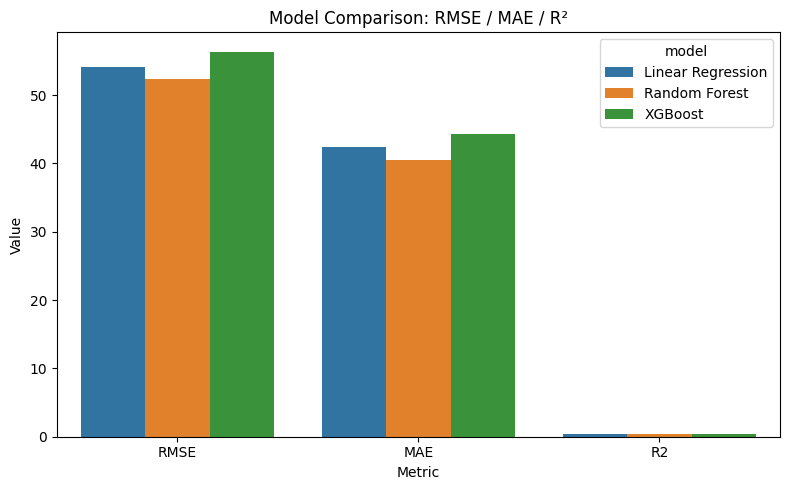

In [27]:
# Bar chart comparison for RMSE, MAE, R2
metrics = ["RMSE", "MAE", "R2"]
plot_df = results_df.set_index("model")[metrics].reset_index().melt(
    id_vars="model", var_name="Metric", value_name="Value"
)

plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="model")
plt.title("Model Comparison: RMSE / MAE / R²")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "model_metrics_comparison.png"), dpi=150)
plt.show()

# Predicted vs Actual Crime Counts — Scatter Plot Comparison
Visualizes how closely predictions align with actual crime counts.
Points close to the diagonal line indicate accurate predictions.
Highlights differences between models in prediction spread and bias.

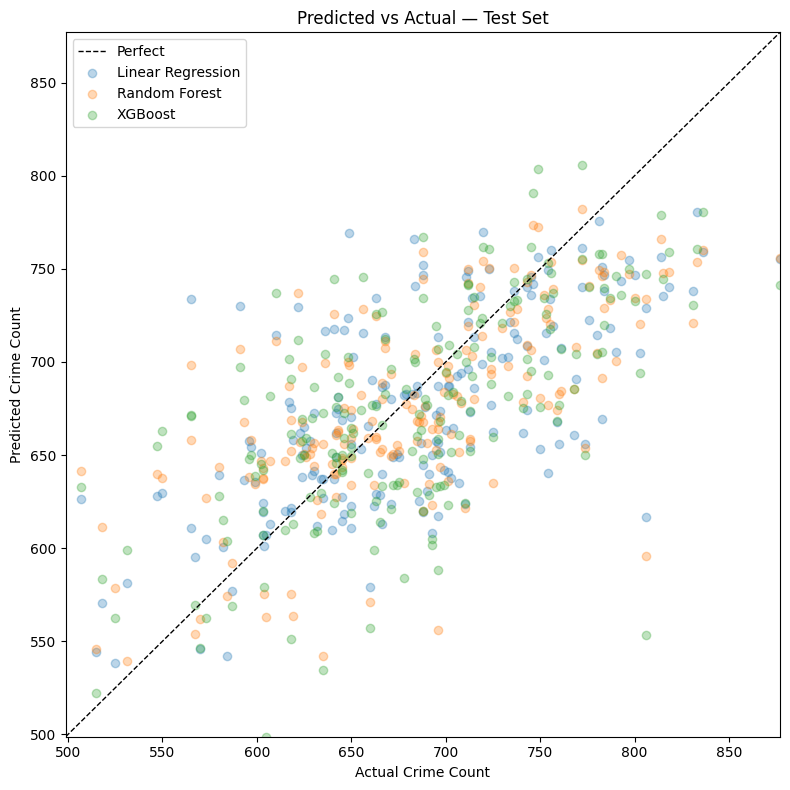

In [28]:
# Predicted vs Actual scatter (all models)
plt.figure(figsize=(8,8))
lims = [
    min(y_test.min(), pred_lr.min(), pred_rf.min(), pred_xgb.min()),
    max(y_test.max(), pred_lr.max(), pred_rf.max(), pred_xgb.max())
]

plt.plot(lims, lims, "k--", linewidth=1, label="Perfect")

plt.scatter(y_test, pred_lr, alpha=0.3, label="Linear Regression")
plt.scatter(y_test, pred_rf, alpha=0.3, label="Random Forest")
plt.scatter(y_test, pred_xgb, alpha=0.3, label="XGBoost")

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Predicted vs Actual — Test Set")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "predicted_vs_actual_all_models.png"), dpi=150)
plt.show()


# Actual vs Predicted Crime Counts Over Time — Last 120 Test Samples
Shows trends of actual vs predicted counts over time.

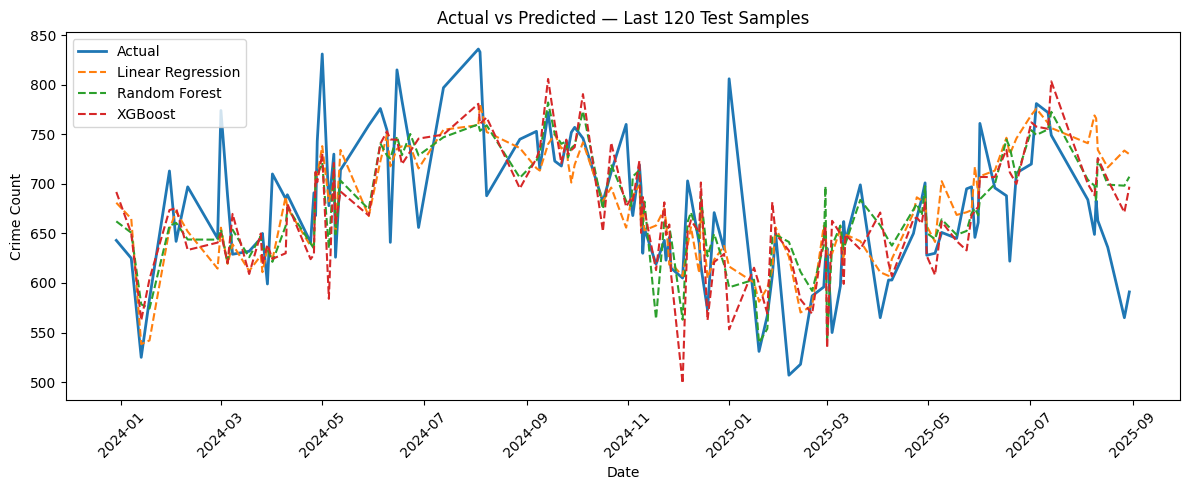

Saved figures to: ../Figures


In [29]:
# Time-series slice: actual vs predictions
pred_df = pd.DataFrame({
    "date": df.loc[X_test.index, "date"],
    "actual": np.array(y_test),
    "LR": pred_lr,
    "RF": pred_rf,
    "XGB": pred_xgb
})

# detect if date is datetime
try:
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df = pred_df.sort_values("date")
    x_axis = "date"
except Exception:
    pred_df['date'] = np.arange(len(pred_df))
    x_axis = "date"

# last N points
N = 120
plot_slice = pred_df.tail(N)

plt.figure(figsize=(12,5))
plt.plot(plot_slice[x_axis], plot_slice["actual"], label="Actual", linewidth=2)
plt.plot(plot_slice[x_axis], plot_slice["LR"], linestyle="--", label="Linear Regression")
plt.plot(plot_slice[x_axis], plot_slice["RF"], linestyle="--", label="Random Forest")
plt.plot(plot_slice[x_axis], plot_slice["XGB"], linestyle="--", label="XGBoost")

plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.title(f"Actual vs Predicted — Last {N} Test Samples")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "timeseries_predictions_slice.png"), dpi=150)
plt.show()

print("Saved figures to:", fig_dir)


# Comparison with Original RF Model

We compare our models (LR, RF, XGBoost) with *Yatri’s RF* to see which predicts crime counts most accurately.

**Metrics:**

* *RMSE / MAE:* Lower is better
* *R²:* Higher is better

This helps identify the most accurate model for predicting crime counts using weather data.


In [33]:
# Yatri's RF metrics (file location - datasets/Weather/Weather_Crime_Analysis)
yatri_rf_metrics = {
    "RMSE": 14.39,
    "MAE": 10.12, #as per Yatri's RF
    "R2": 0.36
}
results_df["model"].unique()

# Our current models' metrics from results_df
current_metrics = results_df.set_index("model").loc[["Linear Regression", "Random Forest", "XGBoost"], ["RMSE","MAE","R2"]]

# Combine into one DataFrame for comparison
model_comparison = current_metrics.copy()
model_comparison.loc["Yatri_RF"] = [yatri_rf_metrics["RMSE"],
                                    yatri_rf_metrics["MAE"],
                                    yatri_rf_metrics["R2"]]

model_comparison


,RMSE,MAE,R2
model,,,
Linear Regression,54.076292,42.414712,0.412180
Random Forest,52.410003,40.452410,0.447848
XGBoost,56.359327,44.230553,0.361498
Yatri_RF,14.390000,10.120000,0.360000


# Comparison with Yatri’s Random Forest (Event Prediction)

Yatri predicted next-day event counts using weather and lag features. My models predict crime counts, so the targets differ, but I can still compare modeling approach and evaluation.

**My insights:**

Yatri’s RMSE/MAE are lower due to the different scale of events vs crime counts, so numeric values aren’t directly comparable.

My Random Forest consistently performs well, showing robustness across different temporal datasets.

It slightly outperforms Linear Regression and is competitive with XGBoost, similar to Yatri’s findings for event prediction.

**Takeaway:**
Comparing with Yatri’s RF highlights the effectiveness of ensemble methods and helps me contextualize my crime prediction results.

# Conclusion

Linear Regression, Random Forest, and XGBoost models were built and evaluated on the dataset. Random Forest achieved the best performance among the tested models. Comparing metrics across models provided a clear view of predictive accuracy, supporting the choice of the most suitable model. The process demonstrated a structured approach to model evaluation and selection.